In [1]:
!pip install pymannkendall
!pip install matplotlib-scalebar


In [12]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import xarray as xr
import datetime
import glob
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.dates import date2num
from statsmodels.tsa.seasonal import seasonal_decompose
from datacube.utils.geometry import Geometry, CRS 
from matplotlib.colors import Normalize
from matplotlib_scalebar.scalebar import ScaleBar
from pymannkendall.pymannkendall import (
    __preprocessing,
    __missing_values_analysis,
    __mk_score,
    __variance_s,
    __z_score,
    __p_value,
    sens_slope,
)

## 1. Load and prepare WIT data 
An output of the WIT tool is a csv file which we will use to detect change at the site. Add the file name into the line that says "ACTION". The 'date' column will be converted so it is able to be read for time series operations such as plotting and ordered into chronological order. 

In [18]:
# editing,  might need components. Split code cell for playing around with

csv_path = "178.csv" 

df = pd.read_csv(csv_path)
df["TIME"] = pd.to_datetime(df["TIME"])

In [19]:
type(df)

pandas.core.frame.DataFrame

In [20]:
print(df)

                       TIME        BS       NPV        PV       WET  WATER
0   1987-09-18 23:17:37.500  0.053016  0.396283  0.535489  0.002229    0.0
1   1987-09-25 23:23:58.000  0.043028  0.403658  0.540190  0.000686    0.0
2   1987-10-04 23:17:58.500  0.076398  0.300965  0.495443  0.114007    0.0
3   1987-11-21 23:18:53.500  0.055615  0.400228  0.530338  0.000000    0.0
4   1987-11-28 23:25:11.000  0.119470  0.379033  0.486789  0.000000    0.0
..                      ...       ...       ...       ...       ...    ...
551 2021-03-30 23:56:39.000  0.000818  0.399971  0.559673  0.033430    0.0
552 2021-04-08 23:50:25.000  0.023163  0.391759  0.539549  0.033646    0.0
553 2021-04-15 23:56:09.000  0.000279  0.398966  0.547704  0.047831    0.0
554 2021-04-15 23:56:33.000  0.000659  0.401637  0.543150  0.048565    0.0
555 2021-04-24 23:50:18.000  0.003365  0.408773  0.521537  0.058426    0.0

[556 rows x 6 columns]


In [22]:
# Function: Mark low-quality data periods 
#def generate_low_quality_data_periods(df):
df = df.copy()                                                #df = dataframe, copies df
df["off_value"] = 0                                           #In the dataframe, set the off value to 0

print(df)

                       TIME        BS       NPV        PV       WET  WATER  \
0   1987-09-18 23:17:37.500  0.053016  0.396283  0.535489  0.002229    0.0   
1   1987-09-25 23:23:58.000  0.043028  0.403658  0.540190  0.000686    0.0   
2   1987-10-04 23:17:58.500  0.076398  0.300965  0.495443  0.114007    0.0   
3   1987-11-21 23:18:53.500  0.055615  0.400228  0.530338  0.000000    0.0   
4   1987-11-28 23:25:11.000  0.119470  0.379033  0.486789  0.000000    0.0   
..                      ...       ...       ...       ...       ...    ...   
551 2021-03-30 23:56:39.000  0.000818  0.399971  0.559673  0.033430    0.0   
552 2021-04-08 23:50:25.000  0.023163  0.391759  0.539549  0.033646    0.0   
553 2021-04-15 23:56:09.000  0.000279  0.398966  0.547704  0.047831    0.0   
554 2021-04-15 23:56:33.000  0.000659  0.401637  0.543150  0.048565    0.0   
555 2021-04-24 23:50:18.000  0.003365  0.408773  0.521537  0.058426    0.0   

     off_value  
0            0  
1            0  
2           

In [50]:
# Landsat 5–8 SLC-off gap
LS5_8_gap_start = datetime.datetime(2011, 11, 1)  #predetermined gap in the satellite imagery with data missing or strippy
LS5_8_gap_end = datetime.datetime(2013, 4, 1)     #datetime.daytime creates a daytime object
df.loc[
    (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
    "off_value",
] = 100

print((df[["TIME", "off_value"]].iloc[350:400]))   #finds a location in the data to print

                       TIME  off_value
350 2009-11-08 23:47:11.500          0
351 2009-12-10 23:47:27.500          0
352 2010-01-11 23:47:39.000          0
353 2010-01-20 23:41:30.500          0
354 2010-03-25 23:41:38.000          0
355 2010-10-19 23:40:36.500          0
356 2010-11-11 23:46:39.500          0
357 2010-12-22 23:40:34.500          0
358 2010-12-29 23:46:46.500          0
359 2011-01-30 23:46:49.500          0
360 2011-03-03 23:46:49.500          0
361 2011-04-04 23:46:41.000          0
362 2011-08-26 23:45:36.500          0
363 2011-09-11 23:45:25.500          0
364 2011-09-20 23:39:06.500          0
365 2011-11-14 23:44:19.500        100
366 2013-04-25 23:58:13.500          0
367 2013-04-25 23:58:37.000          0
368 2013-05-20 23:52:43.000          0
369 2013-06-21 23:52:36.000          0
370 2013-08-31 23:58:31.000          0
371 2013-08-31 23:58:55.000          0
372 2013-10-11 23:52:34.000          0
373 2013-11-03 23:58:13.000          0
374 2013-11-03 23:58:37.0

In [53]:
# Low observation density (less than 4 in 365 days)
for i in range(3, len(df) - 3):                                         #loop, for every item i in a range from the 4th item to the 4th last item, 
    if (df.loc[i + 3, "TIME"] - df.loc[i, "TIME"]).days > 365:          #if the time difference between one observation and the observation 4 after it (i + 3) is bigger than 365, return 100
        df.loc[
            (df["TIME"] >= df.loc[i, "TIME"])
            & (df["TIME"] <= df.loc[i + 3, "TIME"]),
            "off_value",
        ] = 100

print((df[["TIME", "off_value"]].iloc[350:400]))                        #relook at later

                       TIME  off_value
350 2009-11-08 23:47:11.500          0
351 2009-12-10 23:47:27.500          0
352 2010-01-11 23:47:39.000          0
353 2010-01-20 23:41:30.500          0
354 2010-03-25 23:41:38.000          0
355 2010-10-19 23:40:36.500          0
356 2010-11-11 23:46:39.500          0
357 2010-12-22 23:40:34.500          0
358 2010-12-29 23:46:46.500          0
359 2011-01-30 23:46:49.500          0
360 2011-03-03 23:46:49.500          0
361 2011-04-04 23:46:41.000          0
362 2011-08-26 23:45:36.500          0
363 2011-09-11 23:45:25.500        100
364 2011-09-20 23:39:06.500        100
365 2011-11-14 23:44:19.500        100
366 2013-04-25 23:58:13.500        100
367 2013-04-25 23:58:37.000        100
368 2013-05-20 23:52:43.000        100
369 2013-06-21 23:52:36.000          0
370 2013-08-31 23:58:31.000          0
371 2013-08-31 23:58:55.000          0
372 2013-10-11 23:52:34.000          0
373 2013-11-03 23:58:13.000          0
374 2013-11-03 23:58:37.0

In [52]:
print(df)

                       TIME        BS       NPV        PV       WET  WATER  \
0   1987-09-18 23:17:37.500  0.053016  0.396283  0.535489  0.002229    0.0   
1   1987-09-25 23:23:58.000  0.043028  0.403658  0.540190  0.000686    0.0   
2   1987-10-04 23:17:58.500  0.076398  0.300965  0.495443  0.114007    0.0   
3   1987-11-21 23:18:53.500  0.055615  0.400228  0.530338  0.000000    0.0   
4   1987-11-28 23:25:11.000  0.119470  0.379033  0.486789  0.000000    0.0   
..                      ...       ...       ...       ...       ...    ...   
551 2021-03-30 23:56:39.000  0.000818  0.399971  0.559673  0.033430    0.0   
552 2021-04-08 23:50:25.000  0.023163  0.391759  0.539549  0.033646    0.0   
553 2021-04-15 23:56:09.000  0.000279  0.398966  0.547704  0.047831    0.0   
554 2021-04-15 23:56:33.000  0.000659  0.401637  0.543150  0.048565    0.0   
555 2021-04-24 23:50:18.000  0.003365  0.408773  0.521537  0.058426    0.0   

     off_value  
0            0  
1            0  
2           

In [ ]:
# Add low-quality flags
df = generate_low_quality_data_periods(df)

#  Extract selected component 
if component not in df.columns:
raise ValueError(f"Component '{component}' not found in CSV columns: {list(df.columns)}")

pv = df.set_index("TIME")[component].astype(float)

# Identify low-quality data ranges 
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
grouped = (mask != mask.shift()).cumsum()
for _, group in df[mask].groupby(grouped):
    start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
    low_quality_ranges.append((start, end))

#  Filter large gaps 
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]


if len(pv_filtered) < 24:
print(f"Not enough data for {component}, skipping.")
else:
result = seasonal_decompose(pv_filtered, model="additive", period=12)
trend, seasonal, resid = result.trend, result.seasonal, result.resid

Detected 28 abrupt change points in PV residuals.


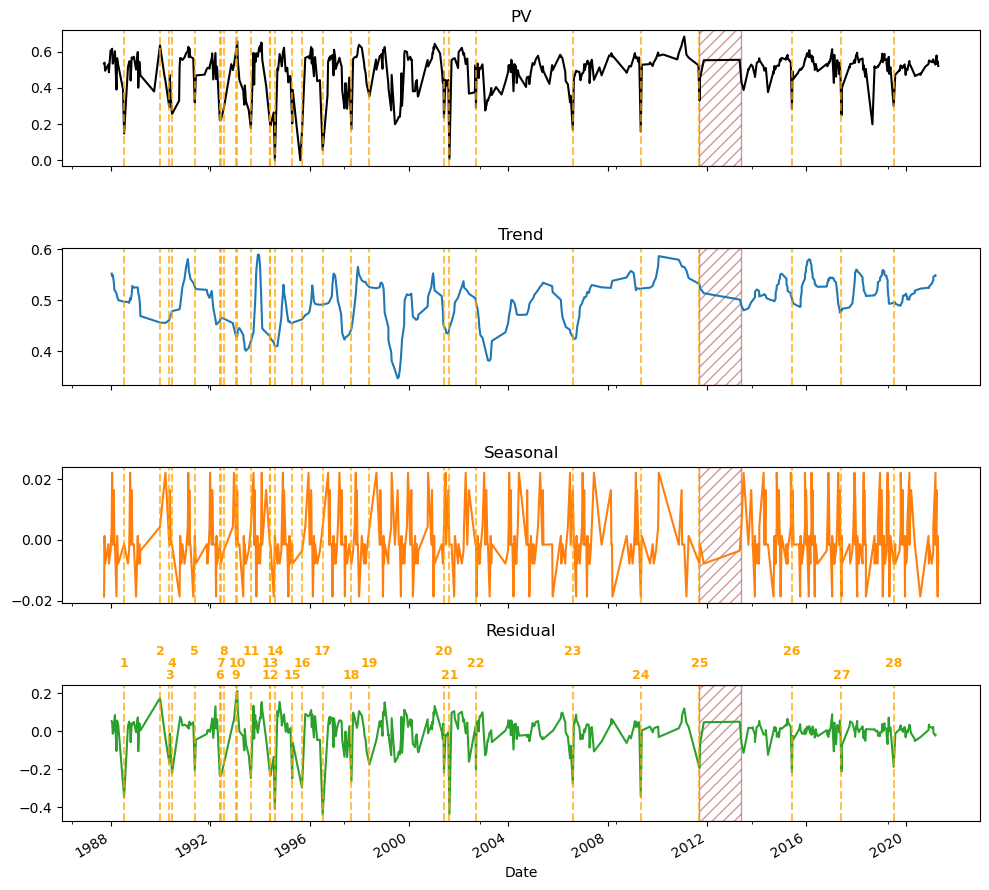

Change point data saved to: 178_PV_change_points.csv


In [13]:
csv_path = "178.csv"      # ACTION: Add CSV output form WIT tool - generates in .../DEA_products/...
component = "PV"       #  CHANGE THIS to the component you want to analyze (e.g. "PV", "GV", "NPV" "WET", "WATER")

# Load and prepare data 
df = pd.read_csv(csv_path)
df["TIME"] = pd.to_datetime(df["TIME"])
df = df.sort_values("TIME").reset_index(drop=True)


# This code is about flagging low data areas in the map. Some of it uses the same code as the WIT tool. 
# I want to clean this section up because it seems like I can do the same thing in a smaller bit of code because it looks like it repeats itself.


# Function: Mark low-quality data periods 
def generate_low_quality_data_periods(df):
    df = df.copy()                                                #df = dataframe, copies df
    df["off_value"] = 0             #In the dataframe, set the off value to 0

    # Landsat 5–8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100

    # Low observation density (less than 4 in 365 days)
    for i in range(3, len(df) - 3):
        if (df.loc[i + 3, "TIME"] - df.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df.loc[i, "TIME"])
                & (df["TIME"] <= df.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100
    return df

# Add low-quality flags
df = generate_low_quality_data_periods(df)

#  Extract selected component 
if component not in df.columns:
    raise ValueError(f"Component '{component}' not found in CSV columns: {list(df.columns)}")

pv = df.set_index("TIME")[component].astype(float)

# Identify low-quality data ranges 
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

#  Filter large gaps 
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

 
if len(pv_filtered) < 24:
    print(f"Not enough data for {component}, skipping.")
else:
    result = seasonal_decompose(pv_filtered, model="additive", period=12)
    trend, seasonal, resid = result.trend, result.seasonal, result.resid


#This chunk of code is from Chad 
    

    # Detect abrupt changes 
    threshold = 2 * resid.std() #2 standard diviations form the mean
    change_points = resid[abs(resid) > threshold].index
    print(f"Detected {len(change_points)} abrupt change points in {component} residuals.")

    # Plot 
    fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
    pv.plot(ax=axes[0], title=f"{component}", color="black")
    trend.plot(ax=axes[1], title="Trend", color="tab:blue")
    seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
    resid.plot(ax=axes[3], color="tab:green")
    axes[3].set_title("Residual", pad=35)

#This code helps illustrate the data, I am wanting to find a cleaner way to give the change detection lines an ID. It looks alot neater without them there but they are them needed for the validation section.
# Whether I produce a graph without them there first depends on the 'story' I am wanting to tell with the notebook   

    # Shade low-quality data
    for ax in axes:
        for start, end in low_quality_ranges:
            ax.axvspan(start, end, facecolor="none", edgecolor="darkred", hatch="///", alpha=0.4)

    # Mark change points
    change_points_sorted = sorted(change_points)
    for idx, cp in enumerate(change_points_sorted, start=1):
        for ax in axes:
            ax.axvline(cp, color="orange", linestyle="--", alpha=0.7)

        # Alternate label positions
        mod = idx % 3
        y_pos = resid.max() * (1.3 + 0.3 * mod)
        axes[3].text(
            cp,
            y_pos,
            str(idx),
            color="orange",
            fontsize=9,
            fontweight="bold",
            ha="center",
            rotation=0,
            clip_on=False,
        )

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()

#  Export detected change points to CSV 
change_data = pd.DataFrame({
    "Change_ID": range(1, len(change_points_sorted) + 1),
    "Timestamp": change_points_sorted
})

# Optional: add component info and CSV path for context
change_data["Component"] = component
change_csv_path = csv_path.replace(".csv", f"_{component}_change_points.csv")

# Save to file
change_data.to_csv(change_csv_path, index=False)
print(f"Change point data saved to: {change_csv_path}")

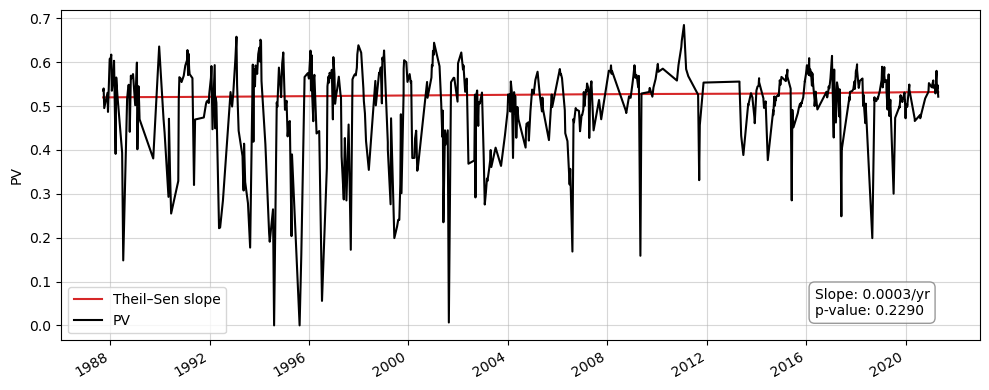

In [14]:
def mk_with_slopes(y, alpha=0.05):
    """
    This function checks the Mann-Kendall (MK) test (Mann 1945, Kendall 1975, Gilbert 1987).
    Modified from pymannkendall to return fewer statistics.
    """
    res = namedtuple('Mann_Kendall_Test', ['p', 'slope', 'intercept'])
    x, c = __preprocessing(y)
    x, n = __missing_values_analysis(x, method='skip')
    
    s = __mk_score(x, n)
    var_s = __variance_s(x, n)
    z = __z_score(s, var_s)
    p, h, trend = __p_value(z, alpha)
    slope, intercept = sens_slope(y)
    return res(p, slope, intercept)

# Run Mann-Kendall on selected component
p, slope, intercept = mk_with_slopes(df[component])

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# Theil–Sen line
y = np.arange(len(df[component])) * slope + intercept
ax.plot(date2num(df["TIME"]), y, color='tab:red', label='Theil–Sen slope')

# Component time series
df.plot(x="TIME", y=component, ax=ax, label=component, color="black")

ax.set_ylabel(component)
ax.set_xlabel(None)
ax.grid(alpha=0.5)

# Annotate slope and p-value
textstr = f"Slope: {slope*12:.4f}/yr\np-value: {p:.4f}"
ax.text(
    0.82, 0.16, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

Limitations
- The national bushfires layer did not include the major bushfire of 2003. Due to my lack of expertese in the area I would have analysed this at face value instead of realsing there was a issue with the underlying data. This meant I could not fully rely on the layer to be able to communicate the 'why'.

- 

/tmp/ipykernel_494/2498181927.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.15, 1, 0.93])


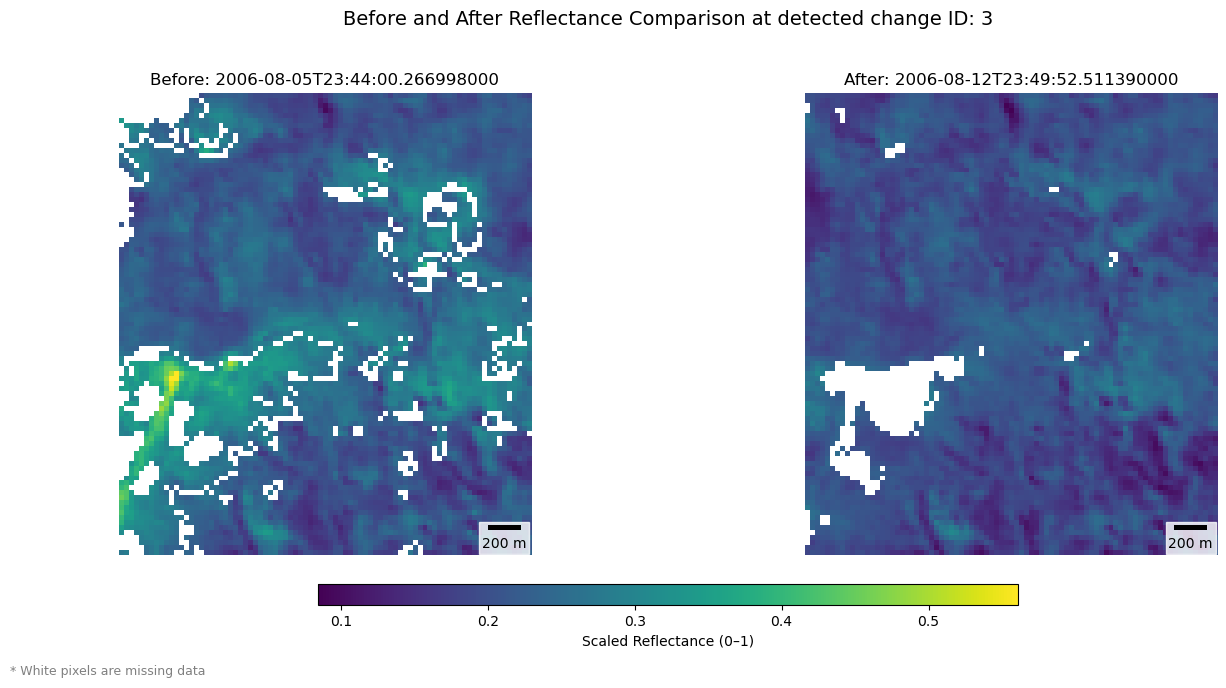

✅ Saved: ./validation_images/change_3_comparison.png


In [17]:

# INPUTS

change_id_to_validate = 3      # ID of change being validated

csv_path = glob.glob("*_change_points.csv")[0]
df = pd.read_csv(csv_path)

out_folder = "./validation_images"


# Example file paths
before_path = f"{out_folder}/change_{change_id_to_validate}_before.nc"
after_path  = f"{out_folder}/change_{change_id_to_validate}_after.nc"


# OPEN DATASETS

before_ds = xr.open_dataset(before_path)
after_ds  = xr.open_dataset(after_path)

# Select your variable (replace with correct band name or computation)
# Example: nbart_nir, nbart_red, NDVI, etc.
var_name = "nbart_nir"  # Change this to whichever band or variable you want

# Your datasets do NOT have time dimension
before_data = before_ds[var_name]
after_data  = after_ds[var_name]

# Extract dates (if stored in the dataset attributes or coords)
before_date = str(before_ds.time.values) if "time" in before_ds else "Unknown date"
after_date  = str(after_ds.time.values) if "time" in after_ds else "Unknown date"

# Convert to true reflectance (0–1 scale)
before_data = before_ds[var_name] / 10000.0
after_data  = after_ds[var_name] / 10000.0

# PLOTTING

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
titles = [f"Before: {before_date}", f"After: {after_date}"]
datasets = [before_data, after_data]

# Shared normalization (ensures consistent color scale)
vmin = float(np.nanmin([before_data.min(), after_data.min()]))
vmax = float(np.nanmax([before_data.max(), after_data.max()]))
norm = Normalize(vmin=vmin, vmax=vmax)

for ax, data, title in zip(axes, datasets, titles):
    im = ax.imshow(data, cmap="viridis", norm=norm)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

    # Add scale bar (approximate pixel size)
    try:
        res_x = abs(before_ds.rio.resolution()[0])
    except:
        res_x = 10  # fallback if rio not available
    scalebar = ScaleBar(res_x, units="m", location="lower right", box_color="white", box_alpha=0.8)
    ax.add_artist(scalebar)


# COLORBAR

cbar_ax = fig.add_axes([0.25, 0.1, 0.5, 0.03])
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"),
                    cax=cbar_ax, orientation='horizontal')
cbar.set_label("Scaled Reflectance (0–1)", fontsize=10)


# EXTRA
fig.text(0.1, 0.0, "* White pixels are missing data", ha='center', fontsize=9, color='gray')

fig.suptitle(f"Before and After Reflectance Comparison at detected change ID: {change_id_to_validate}", fontsize=14, y=0.95)
plt.tight_layout(rect=[0, 0.15, 1, 0.93])


# SAVE PNG

png_path = os.path.join(out_folder, f"change_{change_id_to_validate}_comparison.png")
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Saved: {png_path}")